In [1]:
# ============================================================
# CELL 1 — Install and imports
# ============================================================
!pip install -q timm albumentations

import os
import random
import numpy as np
import pandas as pd
import cv2
import timm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score
from torch.optim.lr_scheduler import CosineAnnealingLR
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [2]:
# ============================================================
# CELL 2 — Download APTOS
# ============================================================
!pip install -q kaggle
from google.colab import files

# Upload your kaggle.json when prompted
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c aptos2019-blindness-detection -p /content/
!unzip -q /content/aptos2019-blindness-detection.zip -d /content/

APTOS_DIR = '/content/train_images'
labels_df = pd.read_csv('/content/train.csv')
print(f"Total images: {len(labels_df)}")
print(labels_df['diagnosis'].value_counts().sort_index())

Saving kaggle.json to kaggle.json
100% 9.51G/9.51G [01:41<00:00, 101MB/s]

Total images: 3662
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [3]:
# ============================================================
# CELL 3 — Dataset class
# ============================================================
IMAGE_SIZE = 224  # compatible with diffusion model distribution

class APTOSDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['id_code'] + '.png')

        # Read with OpenCV, convert to RGB
        img = cv2.imread(img_path)
        if img is None:
            # fallback: return next item
            return self.__getitem__((idx + 1) % len(self))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
        img = Image.fromarray(img)

        if self.transform:
            img = self.transform(img)

        label = int(row['diagnosis'])
        return img, label


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05),
                            scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [4]:
# ============================================================
# CELL 4 — Model: EfficientNet-B0, 5-class classifier
# Standard architecture — compatible with diffusion model input space
# ============================================================
class DRClassifier(nn.Module):
    def __init__(self, num_classes=5, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b0',
            pretrained=True,
            num_classes=0,       # remove head, we add our own
            global_pool='avg'
        )
        in_features = self.backbone.num_features  # 1280 for B0
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(p=dropout / 2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

    def get_features(self, x):
        """Returns raw feature vector before classifier head.
        Used for latent space analysis in prototype."""
        return self.backbone(x)

In [5]:
# ============================================================
# CELL 5 — Class weights to handle APTOS imbalance
# ============================================================
train_df, val_df = train_test_split(
    labels_df,
    test_size=0.15,
    random_state=42,
    stratify=labels_df['diagnosis']
)

print(f"Train: {len(train_df)} | Val: {len(val_df)}")

# Compute class weights
class_counts = train_df['diagnosis'].value_counts().sort_index().values
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print(f"Class weights: {class_weights.round(3)}")

train_dataset = APTOSDataset(train_df, APTOS_DIR, transform=train_transform)
val_dataset   = APTOSDataset(val_df,   APTOS_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True)

Train: 3112 | Val: 550
Class weights: [0.216 1.055 0.39  2.02  1.32 ]


In [7]:
# ============================================================
# CELL 6 — Training loop with label smoothing + QWK tracking
# ============================================================
NUM_EPOCHS   = 25
LR           = 3e-4
SAVE_PATH    = '/content/drive/MyDrive/dr_prototype/classifier.pth'

from google.colab import drive
drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/dr_prototype', exist_ok=True)

model = DRClassifier(num_classes=5, dropout=0.3).to(device)

# Label smoothing helps with noisy APTOS labels
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=0.1
)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc = (np.array(all_preds) == np.array(all_labels)).mean()
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    return avg_loss, acc, qwk

best_qwk = 0.0
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_qwk': []}

print("Starting training...")
print("=" * 65)

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        # Gradient clipping — stabilizes training
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    val_loss, val_acc, val_qwk = evaluate(model, val_loader)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_qwk'].append(val_qwk)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.3f} | "
          f"Val QWK: {val_qwk:.4f}", end="")

    if val_qwk > best_qwk:
        best_qwk = val_qwk
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"  ← SAVED (best QWK)")
    else:
        print()

print(f"\nBest Validation QWK: {best_qwk:.4f}")
print(f"Model saved to: {SAVE_PATH}")

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Starting training...


Epoch 1/25: 100%|██████████| 98/98 [04:24<00:00,  2.70s/it]


...

Epoch 23 | Train Loss: 0.7173 | Val Loss: 1.4110 | Val Acc: 0.825 | Val QWK: 0.8855


Epoch 24/25: 100%|██████████| 98/98 [04:23<00:00,  2.69s/it]


Epoch 24 | Train Loss: 0.7247 | Val Loss: 1.4045 | Val Acc: 0.824 | Val QWK: 0.8883


Epoch 25/25: 100%|██████████| 98/98 [04:21<00:00,  2.67s/it]


Epoch 25 | Train Loss: 0.7200 | Val Loss: 1.4283 | Val Acc: 0.824 | Val QWK: 0.8790

Best Validation QWK: 0.8919
Model saved to: /content/drive/MyDrive/dr_prototype/classifier.pth


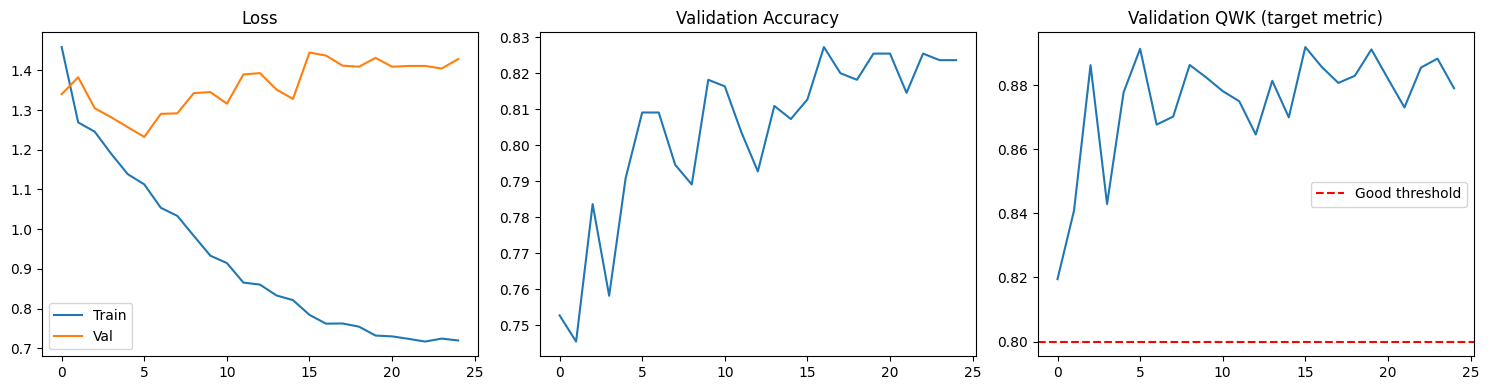

Final Val QWK: 0.8790
Best Val QWK:  0.8919


In [8]:
# ============================================================
# CELL 7 — Plot training curves
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history['val_acc'])
axes[1].set_title('Validation Accuracy')

axes[2].plot(history['val_qwk'])
axes[2].set_title('Validation QWK (target metric)')
axes[2].axhline(y=0.8, color='r', linestyle='--', label='Good threshold')
axes[2].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dr_prototype/training_curves.png', dpi=120)
plt.show()
print(f"Final Val QWK: {history['val_qwk'][-1]:.4f}")
print(f"Best Val QWK:  {best_qwk:.4f}")

In [9]:
# ============================================================
# CELL 8 — Load best model and run final sanity check
# ============================================================
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

# Show predictions on 10 sample images
sample_ids = []
for grade in range(5):
    ids = labels_df[labels_df['diagnosis'] == grade]['id_code'].values[:2]
    sample_ids.extend(ids)

print("Final model predictions:")
print(f"{'Image ID':<30} {'True Grade':<12} {'Predicted Grade':<16} {'Correct?'}")
print("-" * 65)

correct = 0
for img_id in sample_ids:
    true_grade = labels_df[labels_df['id_code'] == img_id]['diagnosis'].values[0]
    img_path = os.path.join(APTOS_DIR, img_id + '.png')
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
    img = Image.fromarray(img)
    tensor = val_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        pred = output.argmax(dim=1).item()

    ok = "✓" if pred == true_grade else "✗"
    if pred == true_grade:
        correct += 1
    print(f"{img_id:<30} {true_grade:<12} {pred:<16} {ok}")

print(f"\nAccuracy on sample: {correct}/{len(sample_ids)}")

Final model predictions:
Image ID                       True Grade   Predicted Grade  Correct?
-----------------------------------------------------------------
002c21358ce6                   0            0                ✓
005b95c28852                   0            0                ✓
0024cdab0c1e                   1            1                ✓
00cb6555d108                   1            1                ✓
000c1434d8d7                   2            2                ✓
00a8624548a9                   2            2                ✓
0104b032c141                   3            3                ✓
03c85870824c                   3            3                ✓
001639a390f0                   4            4                ✓
0083ee8054ee                   4            4                ✓

Accuracy on sample: 10/10
